# Bandit Experiments

Example notebook demonstrating usage of the ibrl library in some basic experiments. 

Shows how to use existing/pre-specified agents and environments, including:
- **Classical agents**: Q-learning, Bayesian, EXP3, Experimental2
- **UCB**: Classic Upper Confidence Bound (deterministic, one-hot policies)
- **IUCB**: Imprecise UCB (Kosoy 2024) — cycle-based algorithm with confidence set geometry, designed for Newcomb-like games

Note that it is possible to define your own agents and/or environments and run similar experiments.

In [1]:
import numpy as np

from ibrl.simulators import simulate
from ibrl.utils import construct_environment, construct_agent

## Configuration

Edit the lists below to choose which environments and agents to run.

In [8]:
# EG, some currently available environments (may change):
#   "bandit", "switching", "newcomb", "damascus",
#   "asymmetric-damascus", "coordination", "pdbandit"
# You can also pass options, e.g. "newcomb:transparency=0.9"
# IUCB takes a very long time (several minutes) to run

environments = [
    "bandit",
    "newcomb",
    "switching",
    "damascus",
    "asymmetric-damascus", 
    #"coordination", 
    #"pdbandit",
]

# EG, some currently available agents (may change):
#   "classical", "bayesian", "exp3", "experimental1", "experimental2",
#   "ucb", "iucb"
# You can also pass options, e.g. "classical:epsilon=0.1", "ucb:exploration=1.0"

agents = [
    "classical",
    "bayesian",
    "exp3",
    "ucb",
    "iucb",
    "matrix-ucb",
]

# Shared options
options = {
    "num_actions": 2,
    "num_steps":   500,
    "num_runs":    20,
    "seed":        42,
    "verbose":     0,
}

# Reward ranges per environment, for agents (like IUCB) that need explicit scaling.
# These should cover the full range of rewards each environment can produce.
env_reward_ranges = {
    "bandit":              (-4.0, 4.0),    # Gaussian arms: mean ~ N(0,1), std 1
    "newcomb":             (0.0, 15.0),    # reward table entries: {0, 5, 10, 15}
    "switching":           (-0.5, 1.5),    # Gaussian: mean in {0, 1}, std 0.1
    "damascus":            (0.0, 10.0),    # reward table entries: {0, 10}
    "asymmetric-damascus": (0.0, 10.0),    # reward table entries: {0, 5, 10}
    "coordination":        (0.0, 2.0),     # reward table entries: {0, 1, 2}
    "pdbandit":            (-4.0, 4.0),    # Gaussian table: mean ~ N(0,1), std 1
}

## Run experiments

In [9]:
all_results = {}

for env_name in environments:
    all_results[env_name] = {}
    for agent_name in agents:
        label = f"{env_name} / {agent_name}"
        print(f"Running: {label}")

        env = construct_environment(env_name, options)

        # Pass reward_range for agents that need explicit scaling (e.g. IUCB)
        agent_opts = dict(options)
        if agent_name == "iucb" and env_name in env_reward_ranges:
            agent_opts["reward_range"] = env_reward_ranges[env_name]

        agent = construct_agent(agent_name, agent_opts)
        results = simulate(env, agent, options)
        all_results[env_name][agent_name] = results

        print(f"  optimal reward: {results['optimal_reward']:.4f}")
        print(f"  final avg reward: {results['average_reward'][0, -1]:.4f}")

print("Done.")

Running: bandit / classical
  optimal reward: 0.7278
  final avg reward: 0.7500
Running: bandit / bayesian
  optimal reward: 0.7278
  final avg reward: 0.7500
Running: bandit / exp3
  optimal reward: 0.7278
  final avg reward: 0.7500
Running: bandit / ucb
  optimal reward: 0.7278
  final avg reward: 0.7000
Running: bandit / iucb
  optimal reward: 0.7278
  final avg reward: 0.5500
Running: bandit / matrix-ucb
  optimal reward: 0.7278
  final avg reward: 0.7500
Running: newcomb / classical
  optimal reward: 1.0000
  final avg reward: 0.4550
Running: newcomb / bayesian
  optimal reward: 1.0000
  final avg reward: 0.6400
Running: newcomb / exp3
  optimal reward: 1.0000
  final avg reward: 0.2400
Running: newcomb / ucb
  optimal reward: 1.0000
  final avg reward: 1.0000
Running: newcomb / iucb
  optimal reward: 1.0000
  final avg reward: 1.0000
Running: newcomb / matrix-ucb
  optimal reward: 1.0000
  final avg reward: 1.0000
Running: switching / classical
  optimal reward: 1.0000
  final av

## Plot results

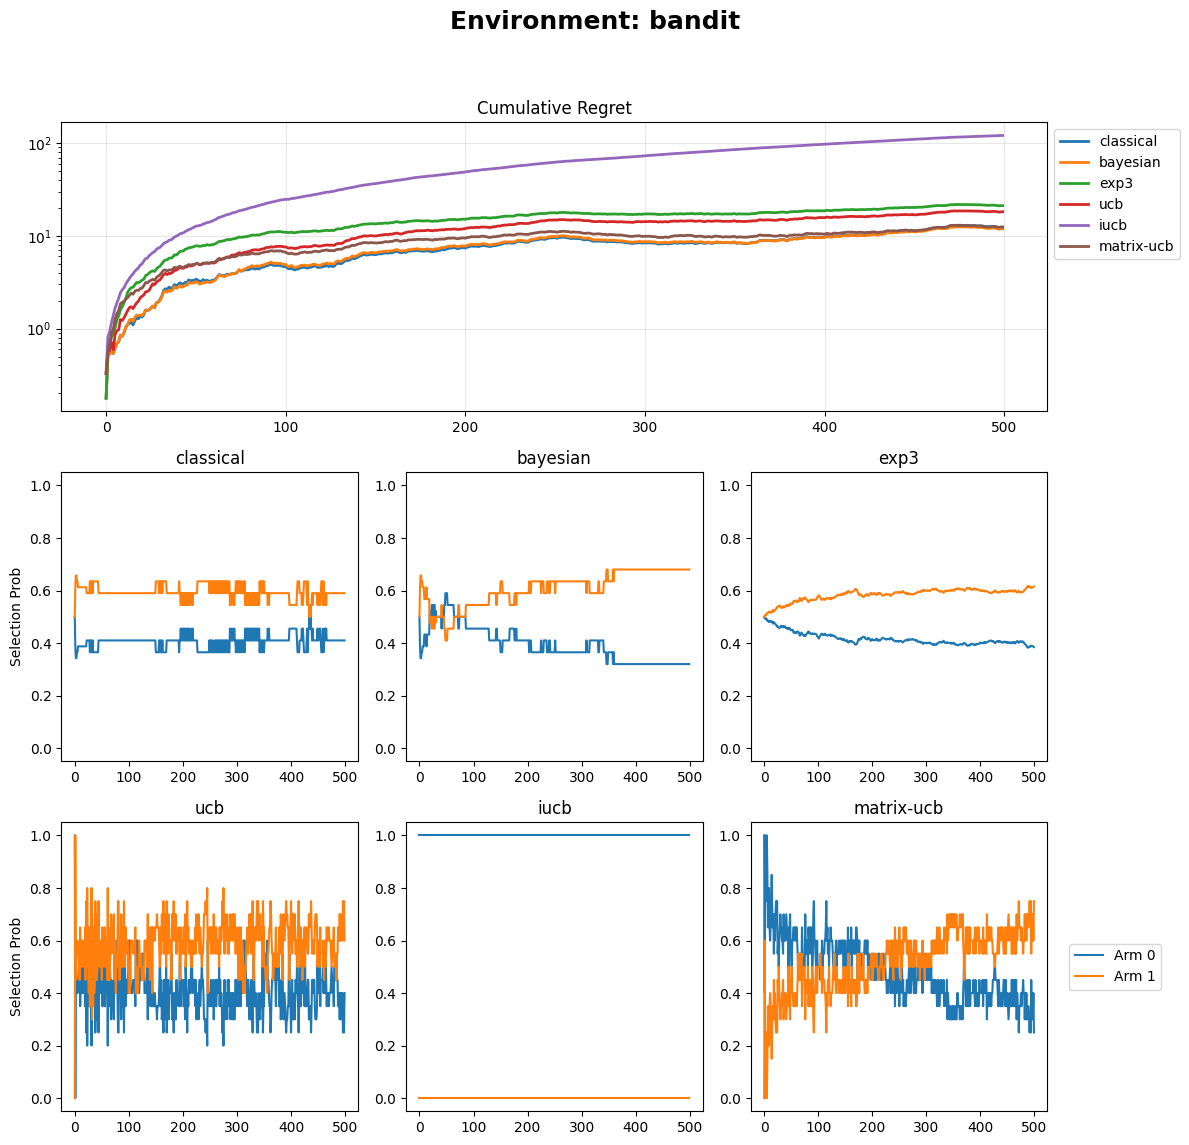

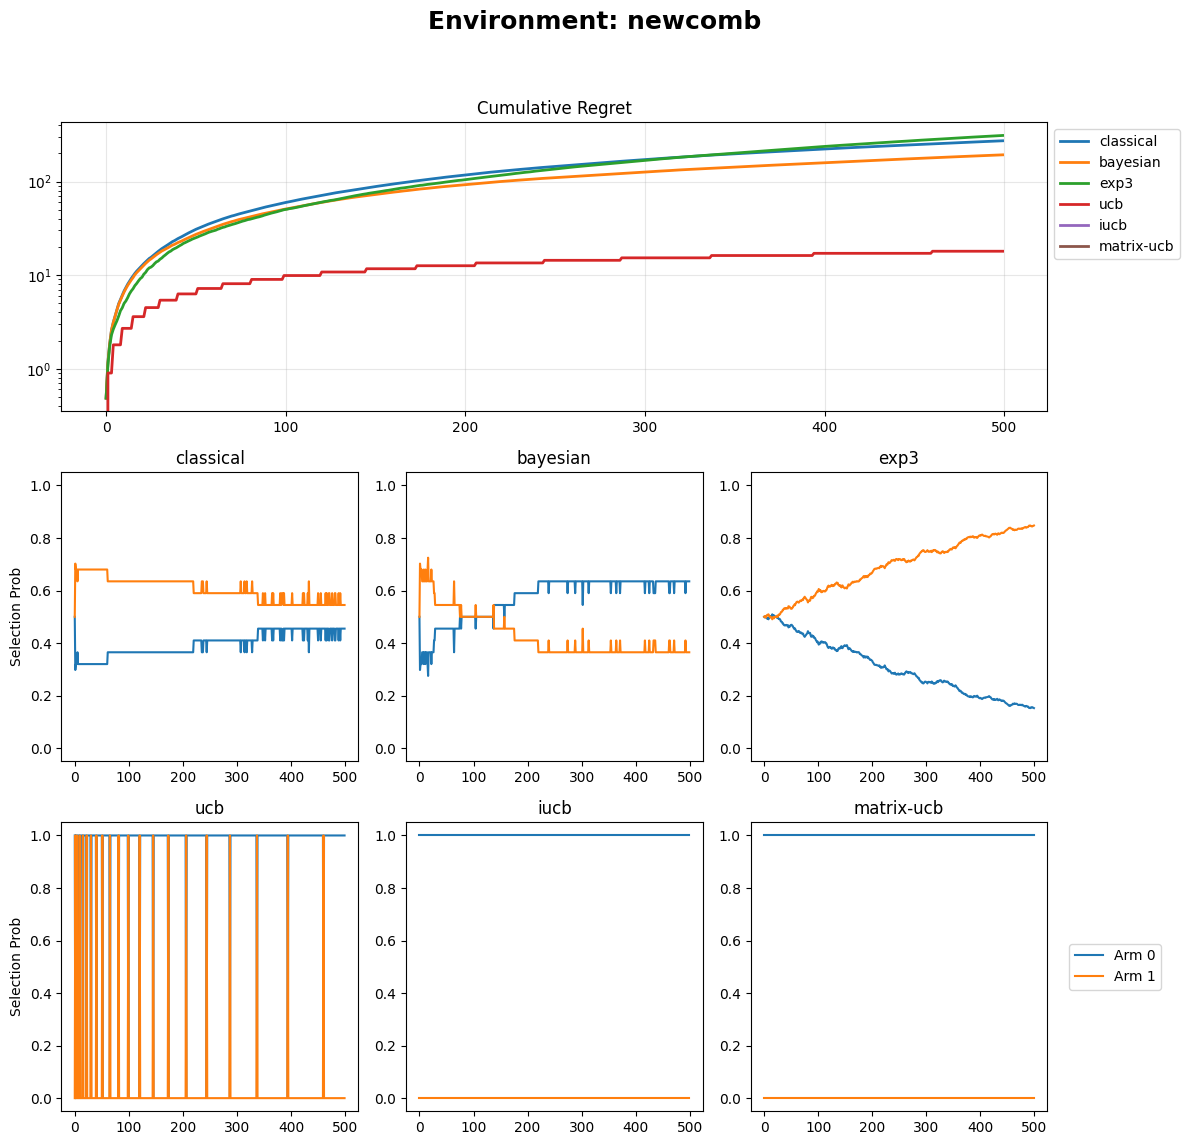

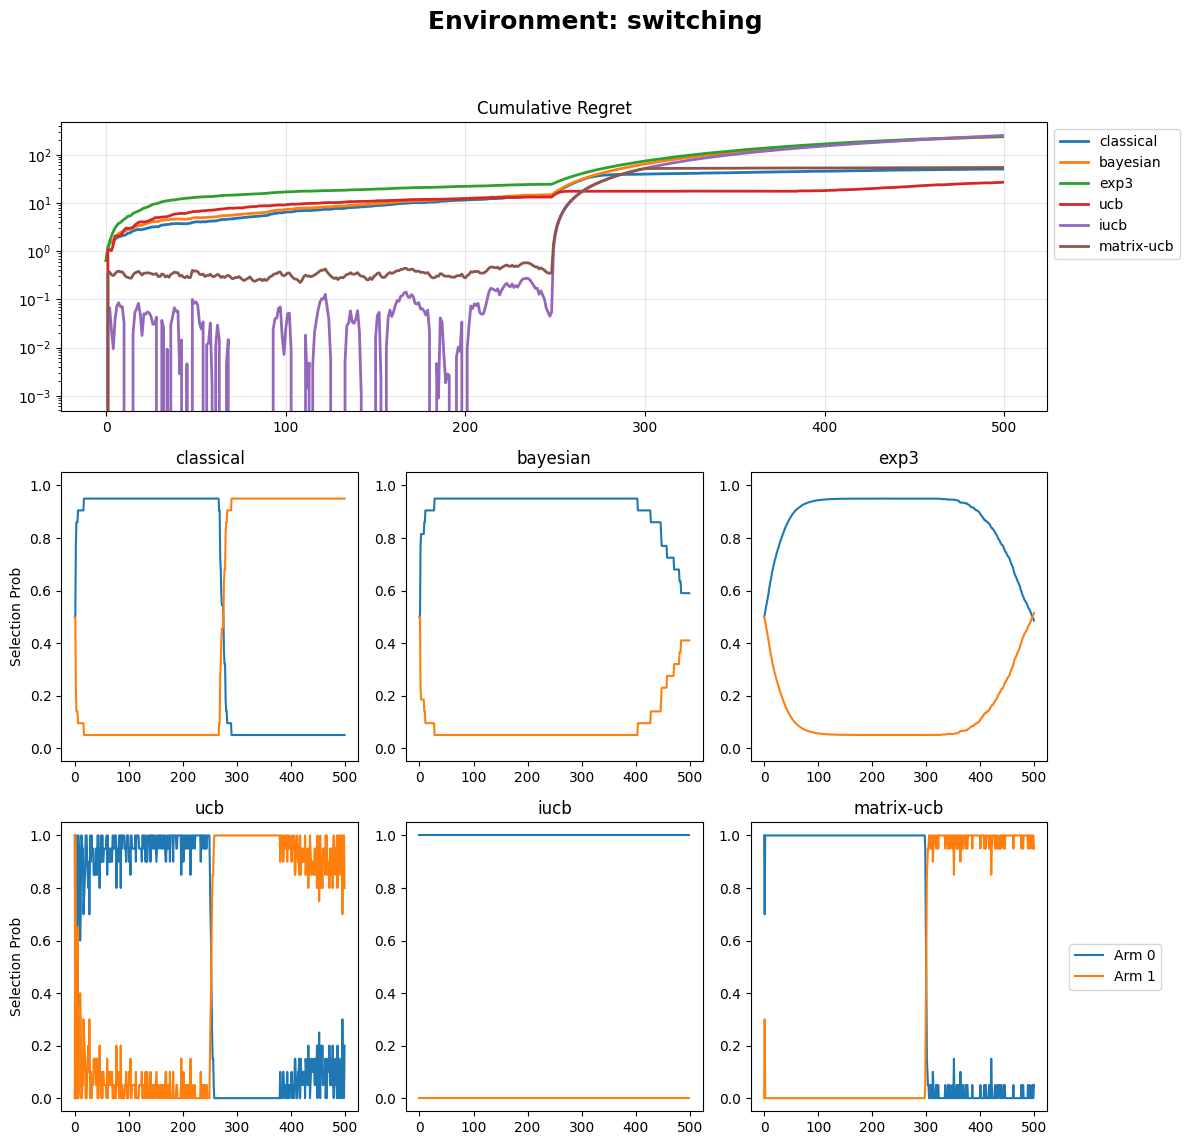

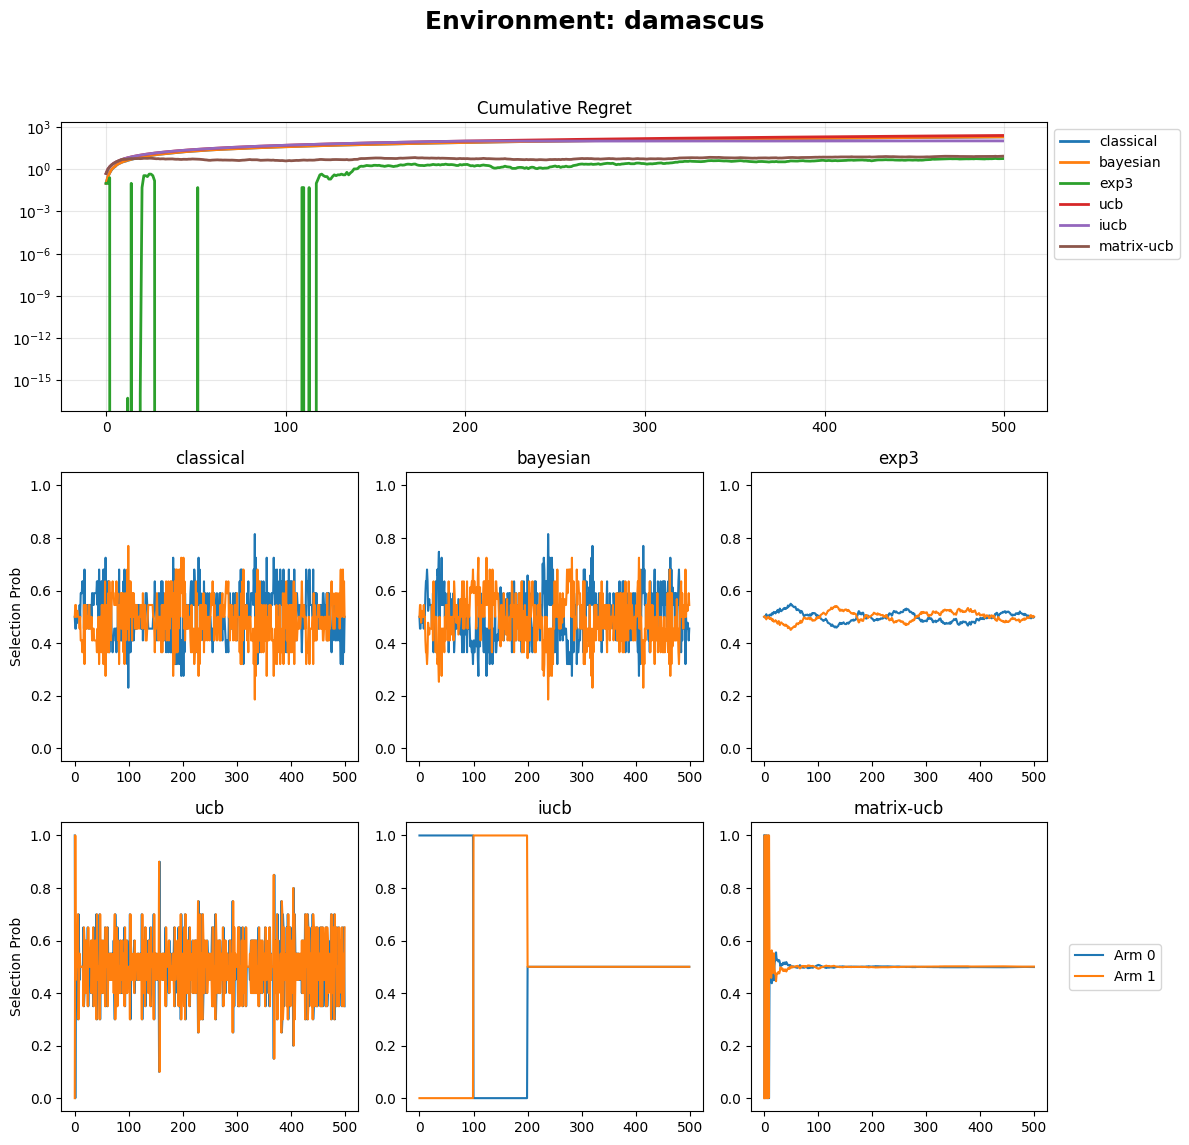

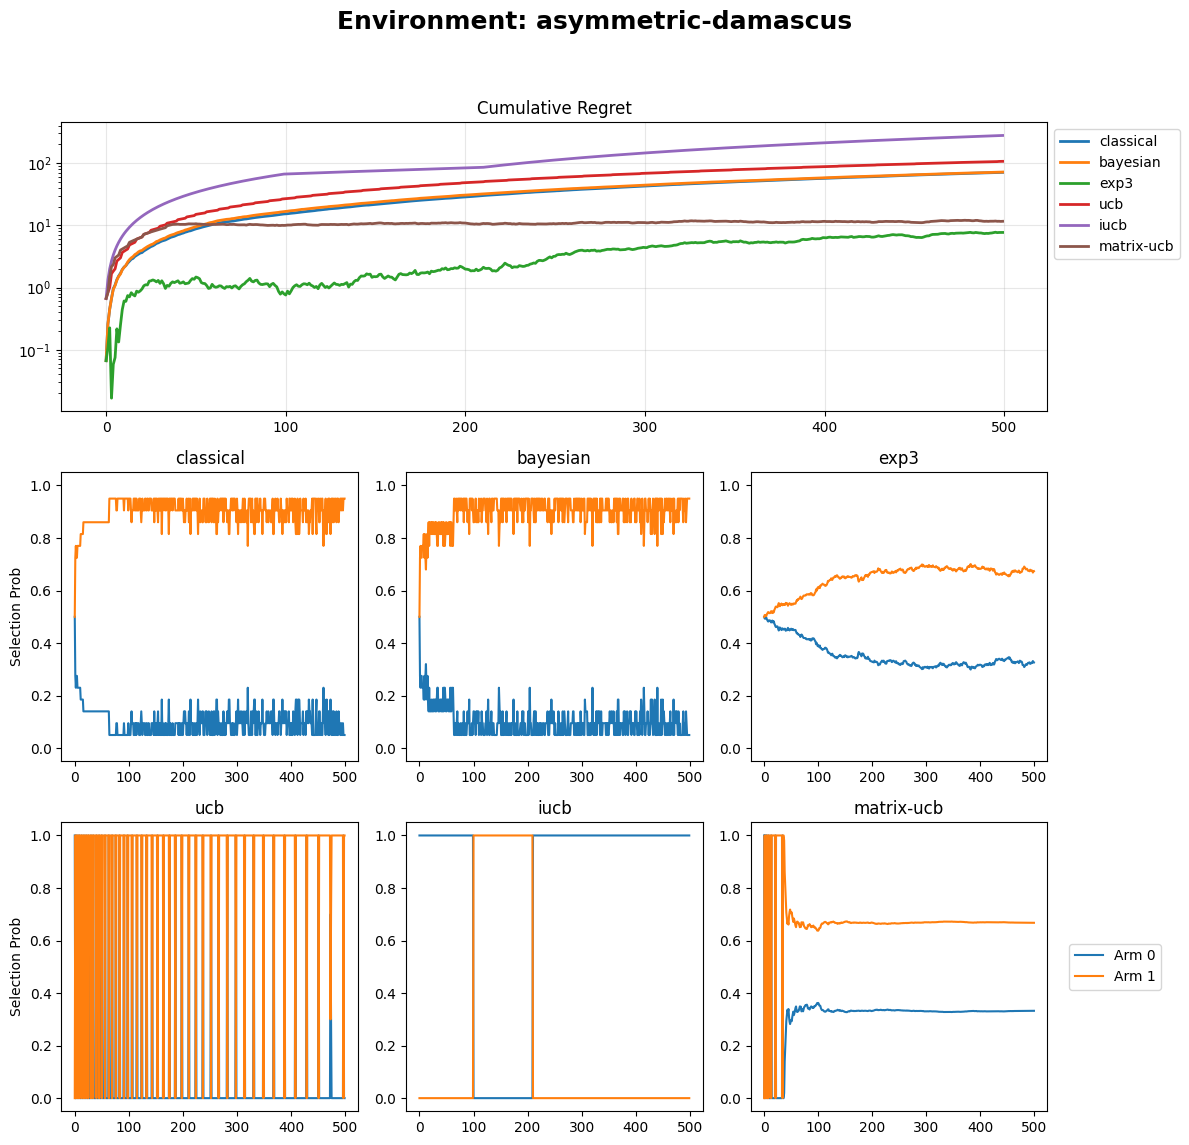

In [11]:
import math
import matplotlib.pyplot as plt

cols = 3

for env_name, agent_results in all_results.items():
    num_agents = len(agent_results)
    num_rows = math.ceil(num_agents / cols) + 1  # +1 for the regret row
    k_val = options["num_actions"]

    fig = plt.figure(figsize=(cols * 4, num_rows * 4))
    fig.suptitle(f"Environment: {env_name}", fontsize=18, fontweight='bold')

    # Top plot: Cumulative Regret (spans first row)
    ax_regret = plt.subplot(num_rows, 1, 1)
    for name, res in agent_results.items():
        avg_reward = res["average_reward"][0, :]
        optimal = res["optimal_reward"]
        cumulative_regret = np.cumsum(optimal - avg_reward)
        ax_regret.plot(cumulative_regret, label=name, linewidth=2)
        ax_regret.set_yscale("log")
    ax_regret.set_title("Cumulative Regret")
    ax_regret.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax_regret.grid(True, alpha=0.3)

    # Bottom subplots: Selection Probabilities per agent
    for i, (name, res) in enumerate(agent_results.items()):
        ax_act = plt.subplot(num_rows, cols, i + cols + 1)
        #actions = res["actions"]  # (num_runs, num_steps, num_actions)
        for arm in range(k_val):
        #    freq = (actions == arm).mean(axis=0)
            ax_act.plot(res["probabilities"][:,:,arm].mean(axis=0), label=f"Arm {arm}")

        ax_act.set_title(f"{name}")
        ax_act.set_ylim(-0.05, 1.05)
        if i % cols == 0:
            ax_act.set_ylabel("Selection Prob")
        if i == num_agents - 1:
            ax_act.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()